# Libraries

In [1]:
import pandas as pd
import json
import datetime
import numpy as np
import matplotlib.pyplot as plt
import os

# Setting Up the Battery and Market Configuration

In [2]:
battery_config = {
    'energy': 1,  # in MWh
    'power': 1,  # in MW
    'cycle_limit': 2, # number of cycles per day
    'service_life': 10, # in years
    'efficiency': 0.95,  # single trip efficiency
    'maxSOC': 1,  # maximum state of charge
    'minSOC': 0,  # minimum state of charge
    'startSOC': 0.5,  # initial state of charge
    'DoD': 1,  # depth of discharge 
    'costs': 250  # costs in €/kWh
}

market_config = {
    'ID1': {'t_delivery': 0.25, 'power_share': 1, 'capture_rate': 1, 'capacity_share': 1}
}

# calculate additional battery parameters. Aging costs are based on initial invest
aging_costs = battery_config['costs'] * 1000 / (battery_config['service_life'] * battery_config['cycle_limit'] * 365)  # in €/MWh
battery_config['aging_costs'] = aging_costs

# Specifying the Date and the Market

In [3]:
day = '2024-09-30'
market = 'ID1'

# Getting the Prices for the Mentioned Date

In [4]:
folder_path = os.path.join('..','marketdata', 'Intraday indices')

# find a csv file that has the day in the name
for file in os.listdir(folder_path):
    if f"DE-{day}" in file:
        file_path = os.path.join(folder_path, file)
        break 

# Read the CSV file without indices
idc_data = pd.read_csv(file_path, parse_dates=False, skiprows=1)
id1_data = idc_data[idc_data['IndexName'] == 'ID1']
id1_data = id1_data[id1_data['TimeResolution'] == '15min']

#convert the column 'DeliveryStart from yyyy-mm-ddThh:mm:ssZ to berlin timezone
id1_data['DeliveryStart'] = pd.to_datetime(id1_data['DeliveryStart']).dt.tz_convert('Europe/Berlin')

# create a series with column 'DeliveryStart' as index and 'IndexPrice' as values
prices = pd.Series(id1_data['IndexPrice'].values, index=id1_data['DeliveryStart'])

In [5]:
folder_path

'..\\marketdata\\Intraday indices'

# Setting the Marketable Power for ID1

In [6]:
max_power_market = battery_config['energy'] * market_config[market]['capacity_share'] / 2 / market_config[market]['t_delivery']
max_power_with_dod = battery_config['energy'] * battery_config['DoD'] / market_config[market]['t_delivery']
max_power_with_soc = battery_config['energy'] * (battery_config['maxSOC'] - battery_config['minSOC']) / market_config[market]['t_delivery']
max_power_battery = battery_config['power'] * market_config[market]['power_share']
power_limit_id1 = min(max_power_market, max_power_with_dod, max_power_with_soc, max_power_battery)
market_config[market]['marketable_power'] = power_limit_id1

# Setting up the Parameters

In [7]:
soc_input = None
blocked_times=None

if 'marketable_power' not in market_config:
    battery_config['marketable_power'] = min(battery_config['energy'] * battery_config['DoD'] / market_config[market]['t_delivery'], 
                                             battery_config['power'] *  market_config[market]['power_share'])  # 50% of the battery capacity is marketable
else:
    battery_config['marketable_power'] = market_config[market]['marketable_power']

# trade volumes including efficiency losses. We always charge or discharge with full power (1 MW)
trade_volume_buy = market_config[market]['t_delivery'] * market_config[market]['marketable_power'] / battery_config['efficiency']
trade_volume_sell = market_config[market]['t_delivery'] * market_config[market]['marketable_power'] * battery_config['efficiency'] 

# soc changes in the battery when charging or discharging with full power (1 MW)
soc_change_buy = market_config[market]['t_delivery'] * battery_config['marketable_power'] / battery_config['energy']
soc_change_sell = market_config[market]['t_delivery'] * battery_config['marketable_power'] / battery_config['energy']

# marginal costs are the minimal costs that have to be earned per trade to be accepted
# this is especially relevant for wholesale. We will see how to apply for FCR and aFRR later
marginal_cost_per_trade = battery_config['aging_costs'] * market_config[market]['t_delivery'] * market_config[market]['marketable_power']  # in €

# soc ranges for the battery
if soc_input is None:
    start_soc = battery_config['startSOC'] 
else:
    start_soc = soc_input[0] 

max_soc = battery_config['maxSOC']
min_soc = battery_config['minSOC']

if 'capacity_share' in market_config[market]:
    max_soc_da = 0.5 + market_config[market]['capacity_share'] / 2 
    min_soc_da = 0.5 - market_config[market]['capacity_share'] / 2

    max_soc = min(max_soc, max_soc_da)
    min_soc = max(min_soc, min_soc_da)


max_power = battery_config['marketable_power']

# create a time dependent energy series for selling and buying energy
energy_sell = pd.Series(index=prices.index, data=trade_volume_sell)
energy_buy = pd.Series(index=prices.index, data=trade_volume_buy)

if soc_input is not None:
    for t in prices.index:
        e_soc_sell = battery_config['energy'] * soc_input.loc[t] * battery_config['efficiency'] 
        e_soc_buy = battery_config['energy'] * (1 - soc_input.loc[t]) / battery_config['efficiency']

        energy_sell.loc[t] = min(energy_sell.loc[t], e_soc_sell)
        energy_buy.loc[t] = min(energy_buy.loc[t], e_soc_buy)

# Calculating the Price Spreads

In [8]:
# turn the prices into a series 
prices = prices.squeeze()

# Calculate the price spreads
price_spreads = pd.DataFrame(columns=['spread', 't_buy', 't_sell'])

for t_sell in prices.index:
    for t_buy in prices.index:

        spread = prices[t_sell] - prices[t_buy]
        t_buy = t_buy
        t_sell = t_sell

        price_spreads = pd.concat([price_spreads, pd.DataFrame({'spread': spread, 
                                                                't_buy': t_buy, 
                                                                't_sell': t_sell, 
                                                                'p_buy': prices[t_buy], 
                                                                'p_sell': prices[t_sell]}, index=[0])], ignore_index=True)
# sort the price spreads
price_spreads = price_spreads.sort_values(by='spread', ascending=False)     

# Finding the Best Price Spreads that Meet the Conditions

In [9]:
# find the best price spreads that meet certain conditions
executed_trades = pd.DataFrame(columns=['spread', 't_buy', 't_sell', 'p_buy', 'p_sell', 'costs', 'revenue', 'profit'])
order_book = pd.DataFrame(columns=['price', 't_exec', 'type', 'volume'])

# Extend the index to include the first timestep of the next day
last_time = prices.index[-1]
next_day_first_timestep = last_time + pd.Timedelta(hours=market_config[market]['t_delivery'])

# Create a new index that includes all original times plus the first hour of the next day
extended_index = prices.index.append(pd.Index([next_day_first_timestep]))

if soc_input is None:
    soc = pd.Series(index=extended_index, data=start_soc)
else:
    soc = pd.Series(index=extended_index, data=soc_input.values)

daily_profit = 0
for i in range(len(price_spreads)):

    soc_temp = soc.copy()

    # Contition A) check if price spread is higher than marginal costs
    if price_spreads.iloc[i]['spread'] < marginal_cost_per_trade:
        print(f"No profitable trades left. Last spread nr {i-1} with value {price_spreads.iloc[i-1]['spread']}")
        break

    t_buy = price_spreads.iloc[i]['t_buy']
    t_sell = price_spreads.iloc[i]['t_sell']

    # Condition 0) check if trades are within block borders
    if blocked_times is not None:
        in_reserved_block = False
        for blocked_time in blocked_times:
            if t_buy in blocked_time or t_sell in blocked_time:
                in_reserved_block = True
                break
        if in_reserved_block:
            continue

    # Calculate the new SOC curve when that trade would be executed
    for t in soc.index:
        previous_hour = t - pd.Timedelta(hours=market_config[market]['t_delivery'])
        if previous_hour in prices.index and previous_hour in soc.index:

            previous_soc = soc[t]
            previous_soc_temp = soc_temp[t]
            next_time = t + pd.Timedelta(hours=market_config[market]['t_delivery'])
            if next_time in soc_temp.index:

                if t == t_buy:
                    soc_temp.loc[next_time] = soc_temp[next_time] - previous_soc + previous_soc_temp + soc_change_buy
                elif t == t_sell:
                    soc_temp.loc[next_time] = soc_temp.loc[next_time] - previous_soc + previous_soc_temp - soc_change_sell
                else:
                    soc_temp.loc[next_time] = soc_temp.loc[next_time] - previous_soc + previous_soc_temp

    # Condition B) check if the SOC changes are within the bounds
    if soc_temp.max() > max_soc or soc_temp.min() < min_soc:
        continue

    # Condition C) check if the SOC changes (DoD) are within the bounds - 
    # this should alreardy be feasible through the marketable power calculation
    if soc_temp.diff().max() > battery_config['DoD'] or abs(soc_temp[0]-battery_config['startSOC']) > battery_config['DoD']:
        continue

    # Contition D) check if soc at the start and at the end are always the same
    start_soc = soc[0]
    end_soc = round(soc_temp.iloc[-1],4)
    if start_soc != end_soc:
        continue

    # calculate the sum of all positive soc changes
    pos_soc_changes = soc_temp.diff()[soc_temp.diff() > 0].sum()  
    if soc_temp[0] > start_soc:
        pos_soc_changes += soc_temp[0] - start_soc

    # CONDITION E) check if SOC changes (cycles) stay within cycle limi    
    if pos_soc_changes > battery_config['cycle_limit']:
        continue
        

    # check if the positive and negative soc chnages are the same
    neg_soc_changes = soc_temp.diff()[soc_temp.diff() < 0].sum()  
    if soc_temp[0] < start_soc:
        neg_soc_changes -=  start_soc - soc_temp[0]
    if pos_soc_changes - neg_soc_changes * -1 > 0.01:
        print(f"Number of positive soc changes: {pos_soc_changes} and negative soc changes: {neg_soc_changes}")

    diff_energy_per_t = soc_temp.diff() * battery_config['energy']
    diff_energy_per_t[0] = soc_temp[0] * battery_config['energy'] - start_soc * battery_config['energy']

    charged_energy_per_t = diff_energy_per_t[diff_energy_per_t > 0] 
    discharged_energy_per_t = diff_energy_per_t[diff_energy_per_t < 0] * -1

    charged_power = charged_energy_per_t / market_config[market]['t_delivery'] 
    discharged_power = discharged_energy_per_t / market_config[market]['t_delivery']

    # CONDITION F) check if the used power is within the limits
    if charged_power.max() > max_power or discharged_power.max() > max_power:
        continue

    # Condition D) Check if SOC at the start of every blocked period is 0.5
    if blocked_times is not None:
        wrong_soc = False
        for blocked_time in blocked_times:
            if soc_temp[blocked_time[0]] != 0.5:
                wrong_soc = True
                break
        if wrong_soc:
            continue

    # execute the trade
    soc = soc_temp.copy()

    order_book = pd.concat([order_book, pd.DataFrame({'price': [price_spreads.iloc[i]['p_buy']], 't_exec': [t_buy], 'type': ['buy']})], ignore_index=True)
    order_book = pd.concat([order_book, pd.DataFrame({'price': [price_spreads.iloc[i]['p_sell']], 't_exec': [t_sell], 'type': ['sell']})], ignore_index=True)
    order_book = order_book.sort_values(by='t_exec')

    # calculate how many consecutive "buy" trades there are in executed_trades
    revenue = trade_volume_sell * price_spreads.iloc[i]['p_sell']
    costs = trade_volume_buy * price_spreads.iloc[i]['p_buy']
    profit = revenue - costs
    daily_profit += profit

    new_executed_trades = pd.DataFrame({'spread': [price_spreads.iloc[i]['spread']], 
                                        't_buy': [t_buy], 't_sell': [t_sell], 
                                        'p_buy': [price_spreads.iloc[i]['p_buy']], 
                                        'p_sell': [price_spreads.iloc[i]['p_sell']],
                                        'revenue': [revenue], 'costs': [costs], 'profit': [profit]}, index=[0])

    executed_trades = pd.concat([executed_trades, new_executed_trades], ignore_index=True)

    print(f"Trade executed at BUY: {t_buy} and SELL: {t_sell}")

print(f"Daily profit: {daily_profit}")

Trade executed at BUY: 2024-09-30 16:00:00+02:00 and SELL: 2024-09-30 07:30:00+02:00
Trade executed at BUY: 2024-09-30 04:00:00+02:00 and SELL: 2024-09-30 08:00:00+02:00
Trade executed at BUY: 2024-09-30 04:15:00+02:00 and SELL: 2024-09-30 07:45:00+02:00
Trade executed at BUY: 2024-09-30 15:00:00+02:00 and SELL: 2024-09-30 09:00:00+02:00
Trade executed at BUY: 2024-09-30 16:15:00+02:00 and SELL: 2024-09-30 19:00:00+02:00
Trade executed at BUY: 2024-09-30 15:15:00+02:00 and SELL: 2024-09-30 19:15:00+02:00
Trade executed at BUY: 2024-09-30 21:45:00+02:00 and SELL: 2024-09-30 18:30:00+02:00
Trade executed at BUY: 2024-09-30 21:30:00+02:00 and SELL: 2024-09-30 18:45:00+02:00
No profitable trades left. Last spread nr 3561 with value 8.6
Daily profit: 192.09407894736842


# Saving the Results in a Dataframe

In [10]:
print(f"Daily profit for {market} on {day} is {daily_profit} EUR")

# Initialise result df
results_df_day = pd.DataFrame()
timestamp_of_15min = pd.date_range(start=day + ' 00:00', periods=96, freq='15min')
results_df_day = pd.DataFrame(columns=list(market_config.keys()), index=timestamp_of_15min)
results_df_day.index = results_df_day.index.tz_localize('Europe/Berlin')

for t in results_df_day.index:    
    results_df_day.loc[t, market] = 0
    results_df_day.loc[t, market] += executed_trades.loc[executed_trades['t_buy'] == t, 'costs'].values.sum() * market_config[market]['capture_rate'] * -1
    results_df_day.loc[t, market] += executed_trades.loc[executed_trades['t_sell'] == t, 'revenue'].values.sum() * market_config[market]['capture_rate']

Daily profit for ID1 on 2024-09-30 is 192.09407894736842 EUR


# Visualise the Results

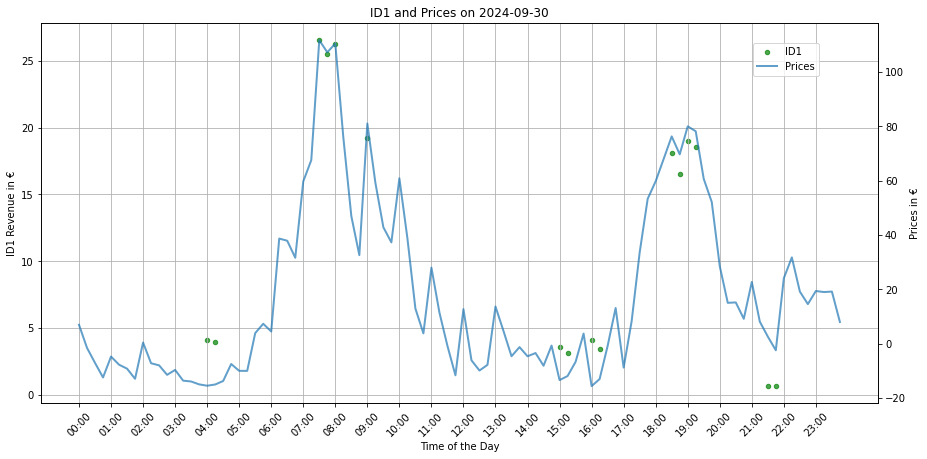

In [11]:
fig, ax1 = plt.subplots(figsize=(15, 7)) 

# make negative values positive and remove zeroes
# results_df_day = results_df_day[results_df_day['IDA1'] != 0]
results_df_day = results_df_day.abs()

# Scatter plot 
ax1.scatter(results_df_day.index, results_df_day['ID1'].where(results_df_day['ID1'] > 0), color='g', alpha=0.7, s=20)
ax1.set_title('ID1 and Prices on ' + str(results_df_day.index[0].date()))
ax1.set_xlabel('Time of the Day')
ax1.set_ylabel('ID1 Revenue in €')
ax1.grid(True)

# Set x-axis ticks to show hourly intervals
hourly_ticks = results_df_day.index[::4] 
ax1.set_xticks(hourly_ticks)
ax1.set_xticklabels(hourly_ticks.strftime('%H:%M'), rotation=45) 

# Add second y-axis for prices as a line
ax2 = ax1.twinx()
ax2.plot(results_df_day.index, prices, linestyle='-', linewidth=2, alpha=0.7)
ax2.set_ylabel('Prices in €')

# Adding legends
fig.legend(['ID1', 'Prices'], loc="upper right", bbox_to_anchor=(0.85, 0.85))

plt.show()


In [12]:
results_df_day

,ID1
2024-09-30 00:00:00+02:00,0
2024-09-30 00:15:00+02:00,0
2024-09-30 00:30:00+02:00,0
2024-09-30 00:45:00+02:00,0
2024-09-30 01:00:00+02:00,0
...,...
2024-09-30 22:45:00+02:00,0
2024-09-30 23:00:00+02:00,0
2024-09-30 23:15:00+02:00,0
2024-09-30 23:30:00+02:00,0
